In [1]:
#Importing the Libraries
import numpy as np
import pandas as pd
import datetime
import matplotlib
import matplotlib.pyplot as plt
from matplotlib import colors
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from yellowbrick.cluster import KElbowVisualizer
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt, numpy as np
from mpl_toolkits.mplot3d import Axes3D
from sklearn.cluster import AgglomerativeClustering
from matplotlib.colors import ListedColormap
from sklearn import metrics
import warnings
import sys
if not sys.warnoptions:
    warnings.simplefilter("ignore")
np.random.seed(42)

In [2]:
import os

print(os.getcwd())

C:\Users\fathi\OneDrive\Desktop\Projects\DataAnalytics_ML\DataAnalysisWithMachineLearning


In [3]:
print(os.listdir())

['.ipynb_checkpoints', 'DataAnalysyswithUnsupervisedLearning.ipynb', 'marketing_campaign (2).csv']


In [4]:
# Loading the dataset
data = pd.read_csv("marketing_campaign (2).csv", sep="\t")

print("Number of datapoints:", len(data))
data.head()

Number of datapoints: 2240


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


In [5]:
print(data.columns.tolist())
print()
print("Year_Birth exists:", "Year_Birth" in data.columns)
print()
print(data[["Year_Birth", "Income", "Kidhome", "Teenhome"]].head())

['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome', 'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1', 'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response']

Year_Birth exists: True

   Year_Birth   Income  Kidhome  Teenhome
0        1957  58138.0        0         0
1        1954  46344.0        1         1
2        1965  71613.0        0         0
3        1984  26646.0        1         0
4        1981  58293.0        1         0


In [6]:
#Information of the column data
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   str    
 3   Marital_Status       2240 non-null   str    
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   str    
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   int64  
 16 

In [7]:
data.columns.tolist()

['ID',
 'Year_Birth',
 'Education',
 'Marital_Status',
 'Income',
 'Kidhome',
 'Teenhome',
 'Dt_Customer',
 'Recency',
 'MntWines',
 'MntFruits',
 'MntMeatProducts',
 'MntFishProducts',
 'MntSweetProducts',
 'MntGoldProds',
 'NumDealsPurchases',
 'NumWebPurchases',
 'NumCatalogPurchases',
 'NumStorePurchases',
 'NumWebVisitsMonth',
 'AcceptedCmp3',
 'AcceptedCmp4',
 'AcceptedCmp5',
 'AcceptedCmp1',
 'AcceptedCmp2',
 'Complain',
 'Z_CostContact',
 'Z_Revenue',
 'Response']

In [8]:
#Rremove the NA/null values
data = data.dropna()
print("The total number of data-points after removing the rows with missing values are:", len(data))

The total number of data-points after removing the rows with missing values are: 2216


In [9]:
# data["Dt_Customer"] = pd.to_datetime(data["Dt_Customer"], dayfirst=True)
# dates = []
# for i in data["Dt_Customer"]:
#     i = i.date()
#     dates.append(i)
# #Dates of the newest and oldest recorded customer
# print("The latest customer's enrolment date:",max(dates))
# print("The oldest customer's enrolment date:",min(dates))

# Convert customer registration date to datetime
data["Dt_Customer"] = pd.to_datetime(
    data["Dt_Customer"],
    dayfirst=True
)

# Find the newest and oldest customer dates
newest_date = data["Dt_Customer"].max()
oldest_date = data["Dt_Customer"].min()

print("Newest customer date:", newest_date.date())
print("Oldest customer date:", oldest_date.date())

Newest customer date: 2014-06-29
Oldest customer date: 2012-07-30


In [10]:
# #Create "Customer_For" column
# days = []
# d1 = max(dates) 
# for i in dates:
#     delta = d1 - i
#     days.append(delta)
# data["Customer_For"] = days
# data["Customer_For"] = pd.to_numeric(data["Customer_For"], errors="coerce")

# Create Customer_For column
# It shows how many days the customer has been registered

data["Customer_For"] = (
    newest_date - data["Dt_Customer"]
).dt.days

# Check the first 5 values
data["Customer_For"].head()

0    663
1    113
2    312
3    139
4    161
Name: Customer_For, dtype: int64

In [11]:
# Customer_For is currently store in nano seconds not days or years
data.Customer_For

0       663
1       113
2       312
3       139
4       161
       ... 
2235    381
2236     19
2237    155
2238    156
2239    622
Name: Customer_For, Length: 2216, dtype: int64

In [12]:
print("Total categories in Marital_Status:\n", data["Marital_Status"].value_counts(), "\n")
print("Total categories in Education:\n", data["Education"].value_counts())

Total categories in Marital_Status:
 Marital_Status
Married     857
Together    573
Single      471
Divorced    232
Widow        76
Alone         3
Absurd        2
YOLO          2
Name: count, dtype: int64 

Total categories in Education:
 Education
Graduation    1116
PhD            481
Master         365
2n Cycle       200
Basic           54
Name: count, dtype: int64


In [13]:
print(data.columns.tolist())

['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome', 'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1', 'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response', 'Customer_For']


In [14]:
print("Year_Birth" in data.columns)

True


In [15]:
#Feature Engineering


#Age of customer today
data["Age"] = 2025-data["Year_Birth"]

#Total spendings on various items
data["Spent"] = data["MntWines"]+ data["MntFruits"]+ data["MntMeatProducts"]+ data["MntFishProducts"]+ data["MntSweetProducts"]+ data["MntGoldProds"]

#Deriving living situation by marital status"Alone"
data["Living_With"]=data["Marital_Status"].replace({"Married":"Partner", "Together":"Partner", "Absurd":"Alone", "Widow":"Alone", "YOLO":"Alone", "Divorced":"Alone", "Single":"Alone",})

#Feature indicating total children living in the household
data["Children"]=data["Kidhome"]+data["Teenhome"]

#Feature for total members in the household
data["Family_Size"] = data["Living_With"].replace({"Alone": 1, "Partner":2})+ data["Children"]

#Feature pertaining parenthood
data["Is_Parent"] = np.where(data.Children> 0, 1, 0)

#Segmenting education levels in three groups
data["Education"]=data["Education"].replace({"Basic":"Undergraduate","2n Cycle":"Undergraduate", "Graduation":"Graduate", "Master":"Postgraduate", "PhD":"Postgraduate"})

#For clarity
data=data.rename(columns={"MntWines": "Wines","MntFruits":"Fruits","MntMeatProducts":"Meat","MntFishProducts":"Fish","MntSweetProducts":"Sweets","MntGoldProds":"Gold"})

#Dropping some of the redundant features
to_drop = ["Marital_Status", "Dt_Customer", "Z_CostContact", "Z_Revenue", "Year_Birth", "ID"]
data = data.drop(to_drop, axis=1)

In [16]:
data.describe()

,Income,Kidhome,Teenhome,Recency,Wines,Fruits,Meat,Fish,Sweets,Gold,...,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Response,Customer_For,Age,Spent,Children,Is_Parent
count,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,...,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000
mean,52247.251354,0.441787,0.505415,49.012635,305.091606,26.356047,166.995939,37.637635,27.028881,43.965253,...,0.073105,0.064079,0.013538,0.009477,0.150271,353.521209,56.179603,607.075361,0.947202,0.714350
std,25173.076661,0.536896,0.544181,28.948352,337.327920,39.793917,224.283273,54.752082,41.072046,51.815414,...,0.260367,0.244950,0.115588,0.096907,0.357417,202.434667,11.985554,602.900476,0.749062,0.451825
min,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,29.000000,5.000000,0.000000,0.000000
25%,35303.000000,0.000000,0.000000,24.000000,24.000000,2.000000,16.000000,3.000000,1.000000,9.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,180.000000,48.000000,69.000000,0.000000,0.000000
50%,51381.500000,0.000000,0.000000,49.000000,174.500000,8.000000,68.000000,12.000000,8.000000,24.500000,...,0.000000,0.000000,0.000000,0.000000,0.000000,355.500000,55.000000,396.500000,1.000000,1.000000
75%,68522.000000,1.000000,1.000000,74.000000,505.000000,33.000000,232.250000,50.000000,33.000000,56.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,529.000000,66.000000,1048.000000,1.000000,1.000000
max,666666.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,262.000000,321.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,699.000000,132.000000,2525.000000,3.000000,1.000000


In [17]:
data[[
    "Age",
    "Spent",
    "Living_With",
    "Children",
    "Family_Size",
    "Is_Parent",
    "Education"
]].head()

,Age,Spent,Living_With,Children,Family_Size,Is_Parent,Education
0,68,1617,Alone,0,1,0,Graduate
1,71,27,Alone,2,3,1,Graduate
2,60,776,Partner,0,2,0,Graduate
3,41,53,Partner,1,3,1,Graduate
4,44,422,Partner,1,3,1,Postgraduate


In [18]:
data["Customer_For"] = data["Customer_For"] / (24 * 60 * 60 * 1e9)

Relative Plot Of Some Selected Features: A Data Subset


<Figure size 800x550 with 0 Axes>

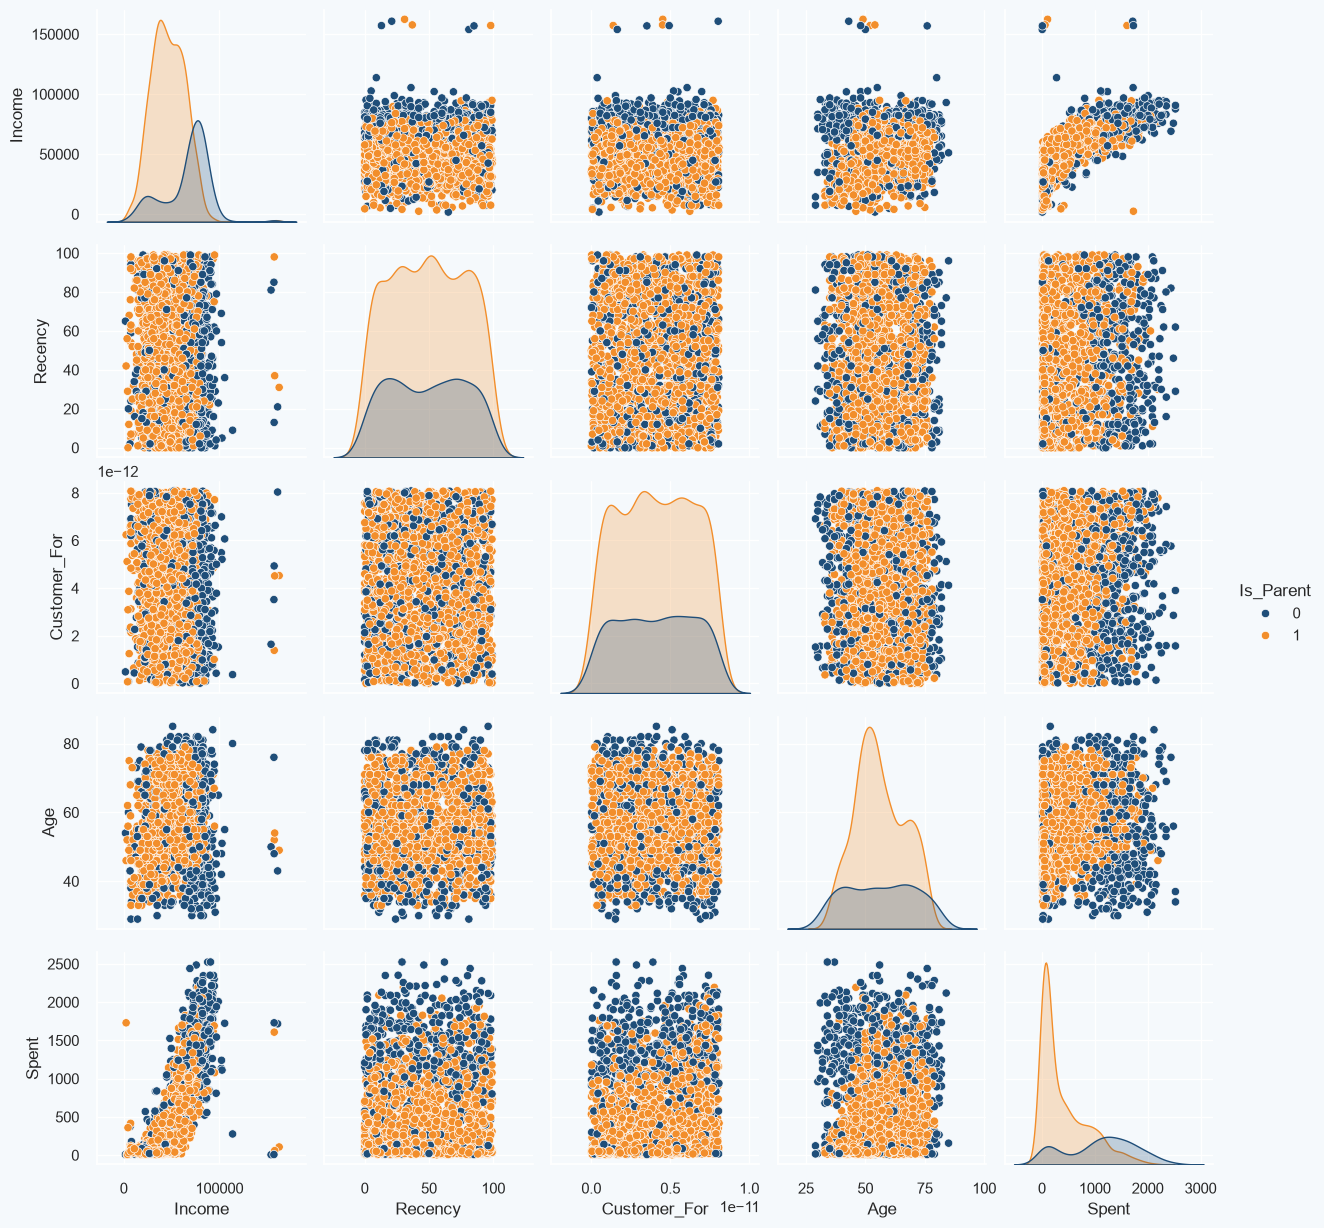

In [28]:
#Visualize some selected features

#Setting the preferenced colors
sns.set(rc={"axes.facecolor":"F5F9FC","figure.facecolor":"#F5F9FC"})
pallet = [ "#1F4E79",  # Dark blue
    "#F28E2B",  # Orange
    "#9DC3E6",  # Light blue
    "#5B9BD5",  # Medium blue
    "#2F75B5",  # Blue
    "#F6B26B" ]
cmap = colors.ListedColormap(["#12355B", "#F28E2B", "#6FA8DC", "#2F75B5", "#A9D6E5", "#F6B26B"])
 

#Plotting following features
To_Plot = [ "Income", "Recency", "Customer_For", "Age", "Spent", "Is_Parent"]
print("Relative Plot Of Some Selected Features: A Data Subset")
plt.figure()
sns.pairplot(data[To_Plot], hue= "Is_Parent",palette= (["#1F4E79", "#F28E2B"]))

#Visualize
plt.show()

In [30]:
#removing outliers on Age and income. - remove extreme Age and Income values so that unusual customers do not strongly affect the clustering analysis.
data = data[(data["Age"]<90)]
data = data[(data["Income"]<600000)]
print("The total number of data-points after removing the outliers are:", len(data))

The total number of data-points after removing the outliers are: 2212


In [31]:
data.info()

<class 'pandas.DataFrame'>
Index: 2212 entries, 0 to 2239
Data columns (total 30 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Education            2212 non-null   str    
 1   Income               2212 non-null   float64
 2   Kidhome              2212 non-null   int64  
 3   Teenhome             2212 non-null   int64  
 4   Recency              2212 non-null   int64  
 5   Wines                2212 non-null   int64  
 6   Fruits               2212 non-null   int64  
 7   Meat                 2212 non-null   int64  
 8   Fish                 2212 non-null   int64  
 9   Sweets               2212 non-null   int64  
 10  Gold                 2212 non-null   int64  
 11  NumDealsPurchases    2212 non-null   int64  
 12  NumWebPurchases      2212 non-null   int64  
 13  NumCatalogPurchases  2212 non-null   int64  
 14  NumStorePurchases    2212 non-null   int64  
 15  NumWebVisitsMonth    2212 non-null   int64  
 16  Acce

In [33]:
# Convert string columns to object type
for column in data.select_dtypes(include=["str"]).columns:
    data[column] = data[column].astype(object)

# Convert Family_Size to integer
data["Family_Size"] = pd.to_numeric(
    data["Family_Size"],
    errors="coerce"
).astype(int)

# Check the data types again
data.info()

<class 'pandas.DataFrame'>
Index: 2212 entries, 0 to 2239
Data columns (total 30 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Education            2212 non-null   object 
 1   Income               2212 non-null   float64
 2   Kidhome              2212 non-null   int64  
 3   Teenhome             2212 non-null   int64  
 4   Recency              2212 non-null   int64  
 5   Wines                2212 non-null   int64  
 6   Fruits               2212 non-null   int64  
 7   Meat                 2212 non-null   int64  
 8   Fish                 2212 non-null   int64  
 9   Sweets               2212 non-null   int64  
 10  Gold                 2212 non-null   int64  
 11  NumDealsPurchases    2212 non-null   int64  
 12  NumWebPurchases      2212 non-null   int64  
 13  NumCatalogPurchases  2212 non-null   int64  
 14  NumStorePurchases    2212 non-null   int64  
 15  NumWebVisitsMonth    2212 non-null   int64  
 16  Acce

In [34]:
#Get list of categorical variables
s = (data.dtypes == 'object')
object_cols = list(s[s].index)

print("Categorical variables in the dataset:", object_cols)

Categorical variables in the dataset: ['Education', 'Living_With']


In [36]:
#Label encoding converts categorical text values into numerical values so that machine-learning algorithms can use them.
LE=LabelEncoder()
for i in object_cols:
    data[i]=data[[i]].apply(LE.fit_transform)

print("All features are now numerical")

All features are now numerical


In [37]:
data.info()

<class 'pandas.DataFrame'>
Index: 2212 entries, 0 to 2239
Data columns (total 30 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Education            2212 non-null   int64  
 1   Income               2212 non-null   float64
 2   Kidhome              2212 non-null   int64  
 3   Teenhome             2212 non-null   int64  
 4   Recency              2212 non-null   int64  
 5   Wines                2212 non-null   int64  
 6   Fruits               2212 non-null   int64  
 7   Meat                 2212 non-null   int64  
 8   Fish                 2212 non-null   int64  
 9   Sweets               2212 non-null   int64  
 10  Gold                 2212 non-null   int64  
 11  NumDealsPurchases    2212 non-null   int64  
 12  NumWebPurchases      2212 non-null   int64  
 13  NumCatalogPurchases  2212 non-null   int64  
 14  NumStorePurchases    2212 non-null   int64  
 15  NumWebVisitsMonth    2212 non-null   int64  
 16  Acce

In [39]:
# Make a copy of the dataset
ds = data.copy()

# creating a subset of dataframe by removing the columns on deals accepted and promotions
cols_del = ['AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1','AcceptedCmp2', 'Complain', 'Response']
ds = ds.drop(cols_del, axis=1)

# Standardise the features
scaler = StandardScaler()
scaler.fit(ds)
scaled_ds = pd.DataFrame(scaler.transform(ds),columns= ds.columns )
print("All features are now scaled")

All features are now scaled


In [40]:
# Show the scaled data for further analysis
print("Dataframe to be used for further modelling:")
scaled_ds.head()

Dataframe to be used for further modelling:


,Education,Income,Kidhome,Teenhome,Recency,Wines,Fruits,Meat,Fish,Sweets,...,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Customer_For,Age,Spent,Living_With,Children,Family_Size,Is_Parent
0,-0.893586,0.287105,-0.822754,-0.929699,0.310353,0.977660,1.552041,1.690293,2.453472,1.483713,...,2.503607,-0.555814,0.692181,1.527721,1.018352,1.676245,-1.349603,-1.264598,-1.758359,-1.581139
1,-0.893586,-0.260882,1.040021,0.908097,-0.380813,-0.872618,-0.637461,-0.718230,-0.651004,-0.634019,...,-0.571340,-1.171160,-0.132545,-1.189011,1.274785,-0.963297,-1.349603,1.404572,0.449070,0.632456
2,-0.893586,0.913196,-0.822754,-0.929699,-0.795514,0.357935,0.570540,-0.178542,1.339513,-0.147184,...,-0.229679,1.290224,-0.544908,-0.206048,0.334530,0.280110,0.740959,-1.264598,-0.654644,-1.581139
3,-0.893586,-1.176114,1.040021,-0.929699,-0.795514,-0.872618,-0.561961,-0.655787,-0.504911,-0.585335,...,-0.913000,-0.555814,0.279818,-1.060584,-1.289547,-0.920135,0.740959,0.069987,0.449070,0.632456
4,0.571657,0.294307,1.040021,-0.929699,1.554453,-0.392257,0.419540,-0.218684,0.152508,-0.001133,...,0.111982,0.059532,-0.132545,-0.951915,-1.033114,-0.307562,0.740959,0.069987,0.449070,0.632456


In [41]:
# Reduce the number of features to 3 using PCA
pca = PCA(n_components=3)
pca.fit(scaled_ds)
PCA_ds = pd.DataFrame(pca.transform(scaled_ds), columns=(["col1","col2", "col3"]))
PCA_ds.describe().T

,count,mean,std,min,25%,50%,75%,max
col1,2212.0,5.781993e-17,2.878602,-5.978124,-2.539470,-0.781595,2.386380,7.452915
col2,2212.0,6.424437e-17,1.709469,-4.194757,-1.323929,-0.173721,1.234851,6.168189
col3,2212.0,-5.139550e-17,1.231687,-3.625248,-0.853713,-0.050842,0.863974,6.750458


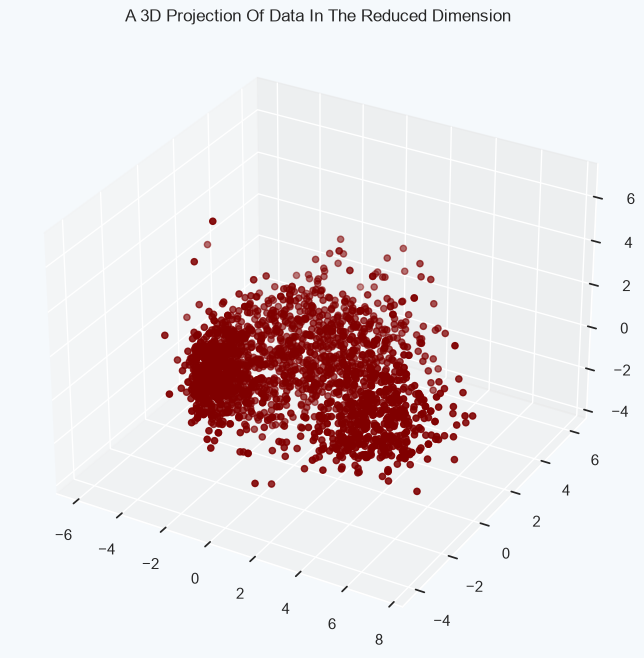

In [43]:
##creates a 3D scatter plot to visualise the customer data using the three PCA components.

# Select the 3 PCA components
x =PCA_ds["col1"]
y =PCA_ds["col2"]
z =PCA_ds["col3"]

# Create a 3D plot
fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(111, projection="3d")

# Plot the data points
ax.scatter(x,y,z, c="maroon", marker="o" )

ax.set_title("A 3D Projection Of Data In The Reduced Dimension")
plt.show()

Elbow Method to determine the number of clusters:


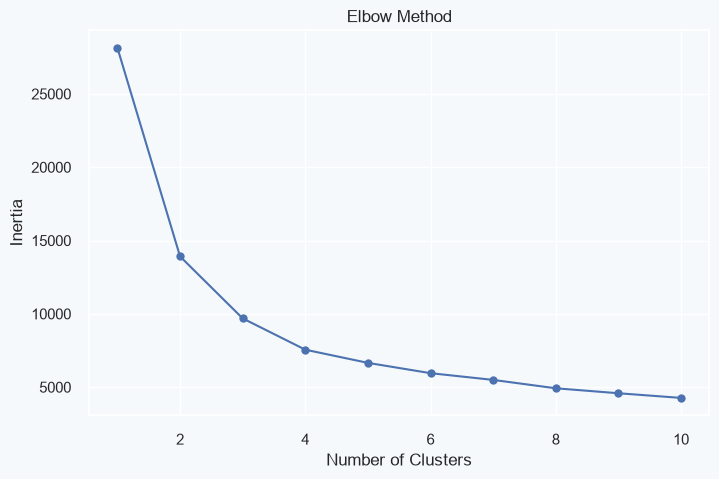

In [47]:
# Use the Elbow Method to find the number of clusters

print(
    "Elbow Method to determine the number of clusters:"
)

inertia = []

for k in range(1, 11):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(PCA_ds)

    inertia.append(kmeans.inertia_)

# Plot the Elbow Method

plt.figure(figsize=(8, 5))

plt.plot(
    range(1, 11),
    inertia,
    marker="o"
)

plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")

plt.show()

In [48]:
# Create 4 customer clusters

kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

kmeans.fit(PCA_ds)

# Add cluster labels

PCA_ds["Cluster"] = kmeans.labels_

print("Customer clusters have been created.")

Customer clusters have been created.


In [49]:
# Count customers in each cluster

PCA_ds["Cluster"].value_counts().sort_index()

Cluster
0    608
1    557
2    506
3    541
Name: count, dtype: int64

In [50]:
# Add cluster labels to the original dataset

data["Cluster"] = PCA_ds["Cluster"].values

data.head()

,Education,Income,Kidhome,Teenhome,Recency,Wines,Fruits,Meat,Fish,Sweets,...,Complain,Response,Customer_For,Age,Spent,Living_With,Children,Family_Size,Is_Parent,Cluster
0,0,58138.0,0,0,58,635,88,546,172,88,...,0,1,7.673611e-12,68,1617,0,0,1,0,2
1,0,46344.0,1,1,38,11,1,6,2,1,...,0,0,1.307870e-12,71,27,0,2,3,1,3
2,0,71613.0,0,0,26,426,49,127,111,21,...,0,0,3.611111e-12,60,776,1,0,2,0,2
3,0,26646.0,1,0,26,11,4,20,10,3,...,0,0,1.608796e-12,41,53,1,1,3,1,0
4,1,58293.0,1,0,94,173,43,118,46,27,...,0,0,1.863426e-12,44,422,1,1,3,1,3


In [51]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

kmeans.fit(PCA_ds)

PCA_ds["Cluster"] = kmeans.labels_

print("Customer clusters have been created.")

Customer clusters have been created.


In [53]:
# Create 4 customer groups using Agglomerative Clustering
AC = AgglomerativeClustering(n_clusters=4)

# Create the cluster labels
yhat_AC = AC.fit_predict(PCA_ds)

# Add the cluster labels to the PCA data
PCA_ds["Clusters"] = yhat_AC

# Add the cluster labels to the original data
data["Clusters"]= yhat_AC

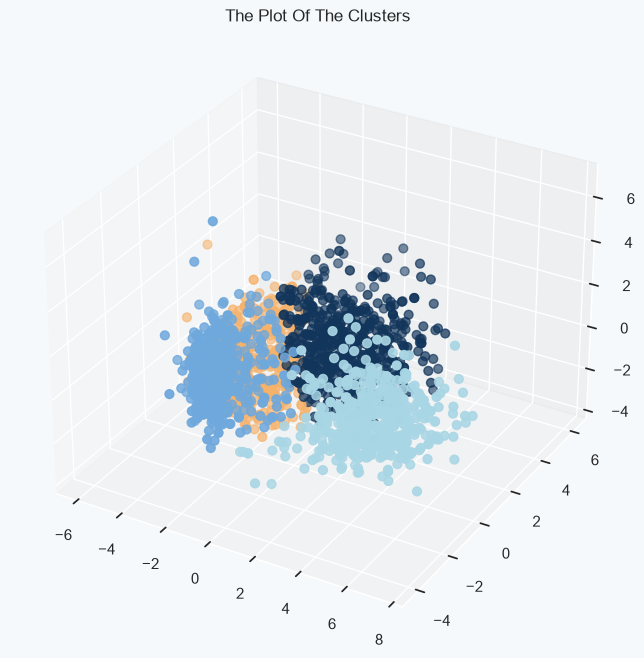

In [54]:
#Plotting the clusters
fig = plt.figure(figsize=(10,8))
ax = plt.subplot(111, projection='3d', label="bla")
ax.scatter(x, y, z, s=40, c=PCA_ds["Clusters"], marker='o', cmap = cmap )
ax.set_title("The Plot Of The Clusters")
plt.show()

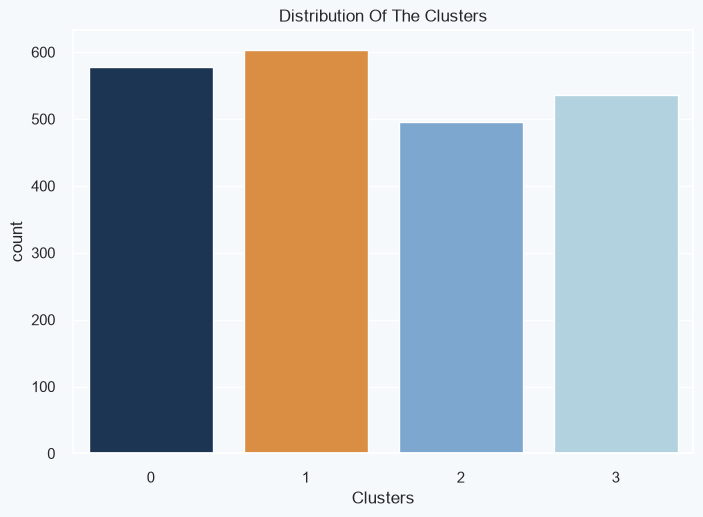

In [55]:
#Plotting countplot of clusters
pal = ["#12355B","#F28E2B", "#6FA8DC","#A9D6E5"]
pl = sns.countplot(x=data["Clusters"], palette= pal)
pl.set_title("Distribution Of The Clusters")
plt.show()

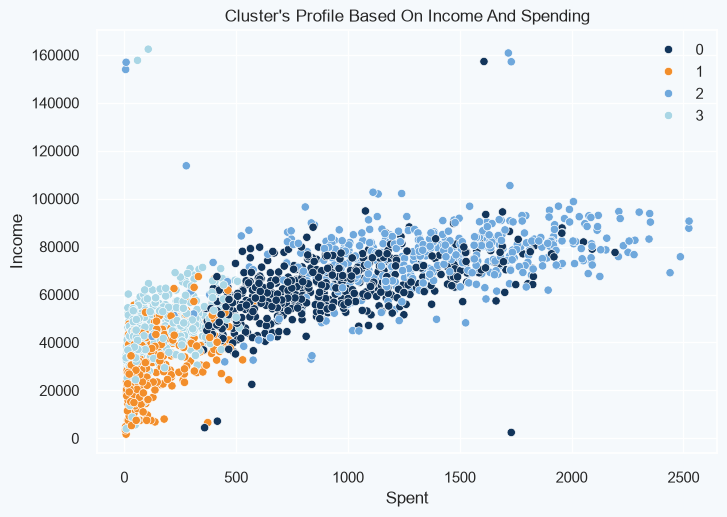

In [57]:
# Create a scatter plot using Spending and Income
pl = sns.scatterplot(data = data,x=data["Spent"], y=data["Income"],hue=data["Clusters"], palette= pal)

# Add a title
pl.set_title("Cluster's Profile Based On Income And Spending")

# Show the legend
plt.legend()

# Display the plot
plt.show()


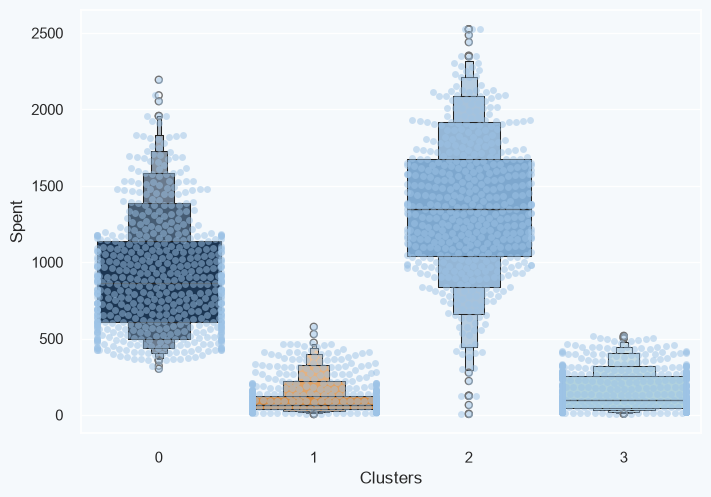

In [59]:
# Create the plot
plt.figure()

# Show individual customer spending values
pl=sns.swarmplot(x=data["Clusters"], y=data["Spent"], color= "#9DC3E6", alpha=0.5 )

# Show spending distribution for each cluster
pl=sns.boxenplot(x=data["Clusters"], y=data["Spent"], palette=pal)
plt.show()

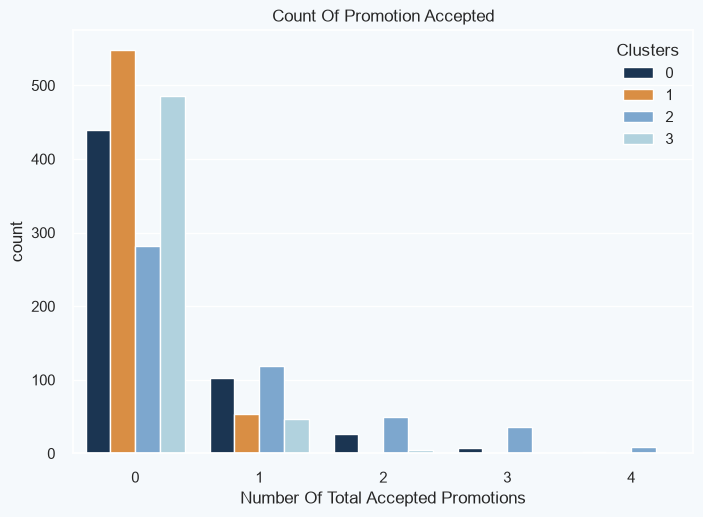

In [60]:
# Calculate the total number of promotions accepted
data["Total_Promos"] = data["AcceptedCmp1"]+ data["AcceptedCmp2"]+ data["AcceptedCmp3"]+ data["AcceptedCmp4"]+ data["AcceptedCmp5"]

# Create a plot of accepted promotions
plt.figure()
pl = sns.countplot(x=data["Total_Promos"],hue=data["Clusters"], palette= pal)

# Add a title
pl.set_title("Count Of Promotion Accepted")

# Add an x-axis label
pl.set_xlabel("Number Of Total Accepted Promotions")
plt.show()

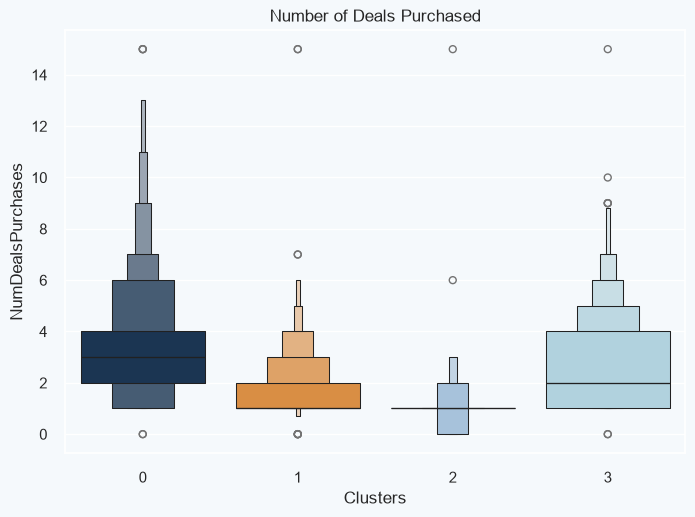

In [61]:
# Show the number of deals purchased by each cluster
plt.figure()
pl=sns.boxenplot(y=data["NumDealsPurchases"],x=data["Clusters"], palette= pal)

# Add a title
pl.set_title("Number of Deals Purchased")
plt.show()

<Figure size 800x550 with 0 Axes>

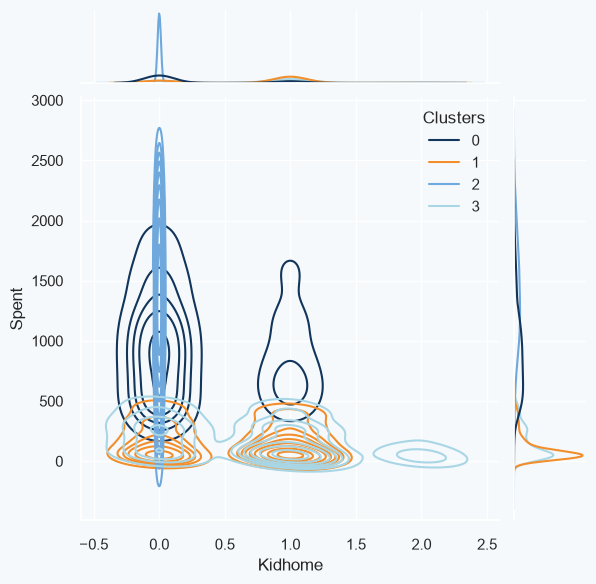

<Figure size 800x550 with 0 Axes>

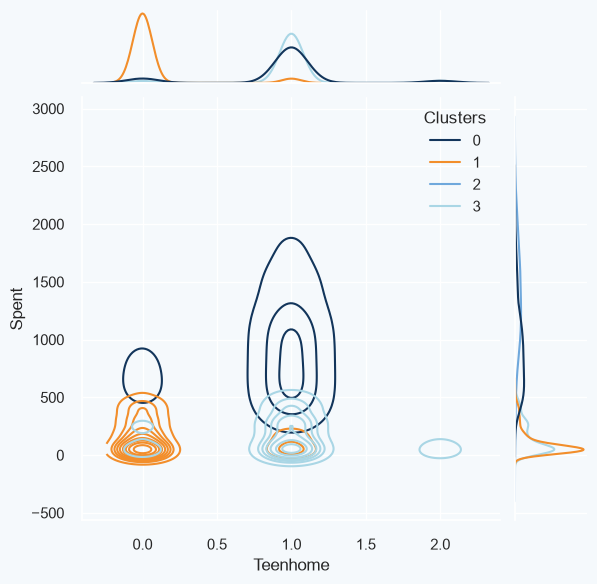

<Figure size 800x550 with 0 Axes>

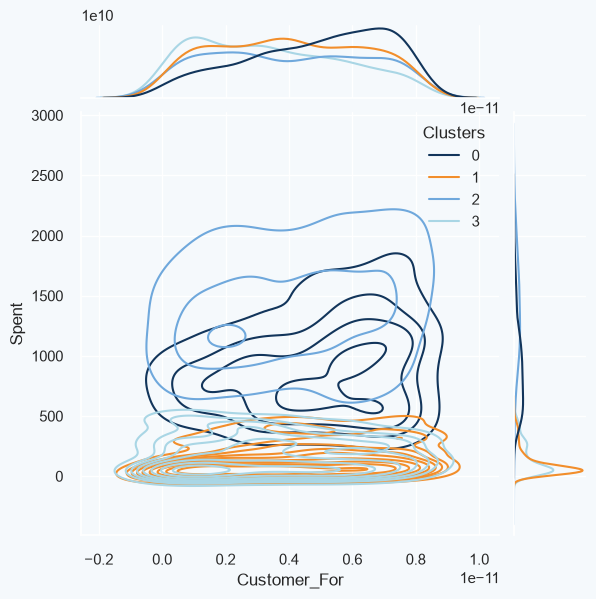

<Figure size 800x550 with 0 Axes>

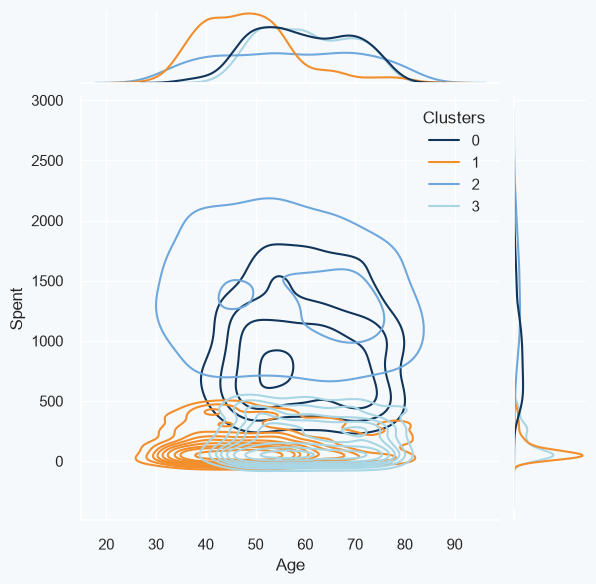

<Figure size 800x550 with 0 Axes>

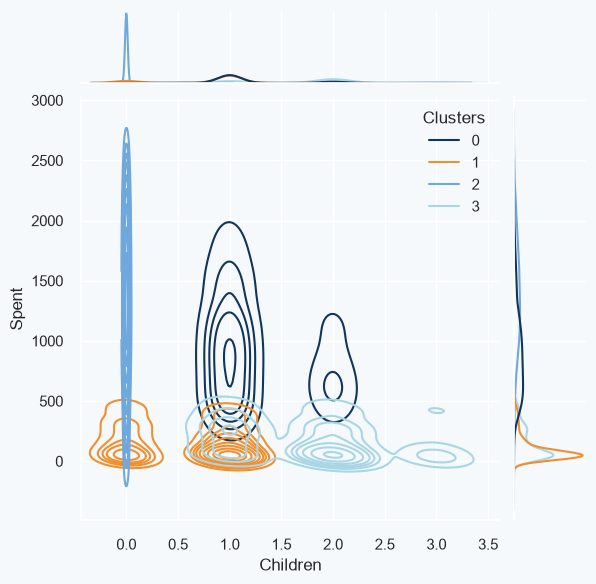

<Figure size 800x550 with 0 Axes>

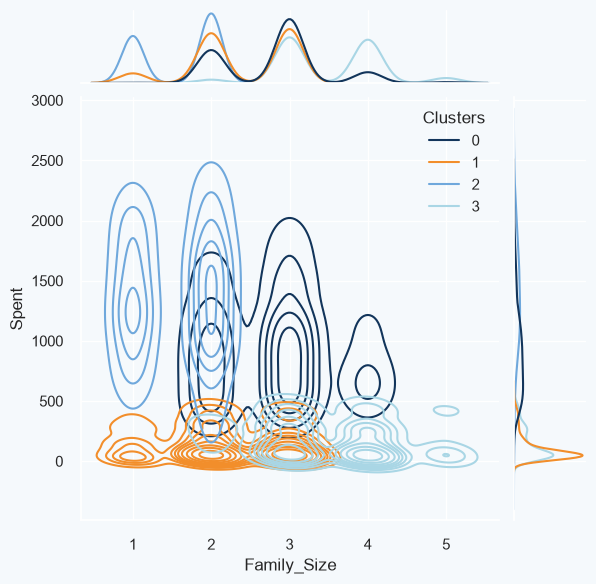

<Figure size 800x550 with 0 Axes>

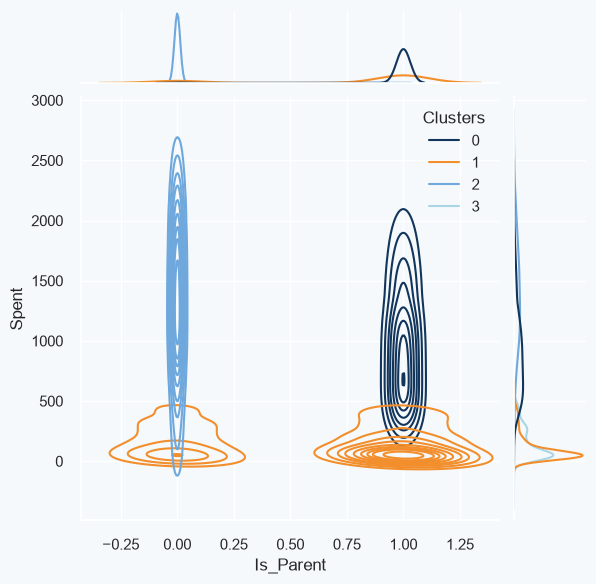

<Figure size 800x550 with 0 Axes>

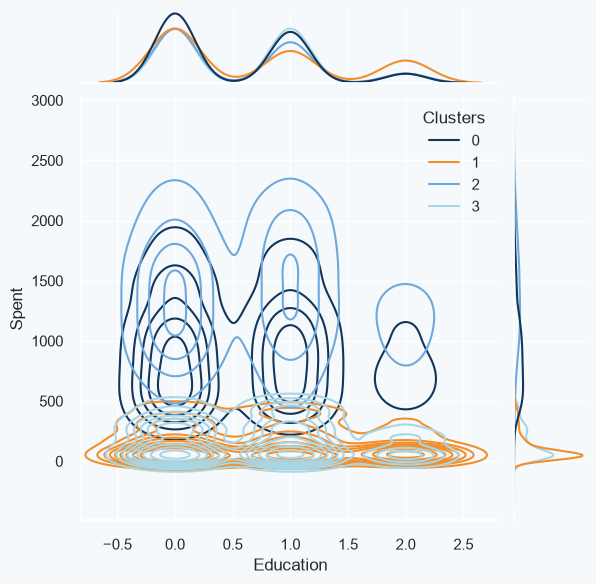

<Figure size 800x550 with 0 Axes>

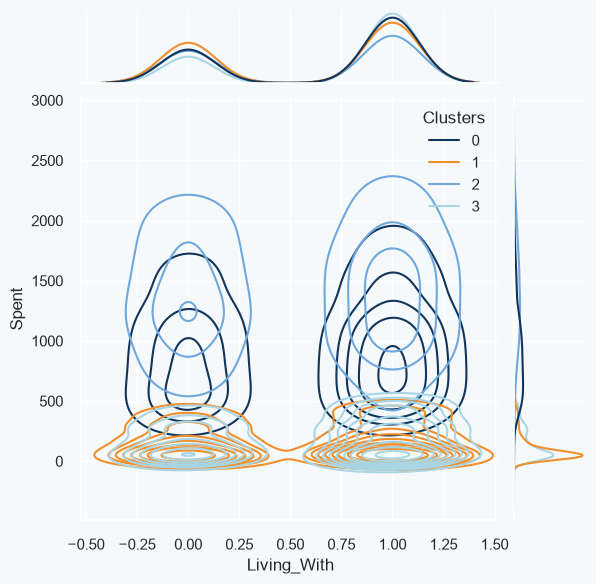

In [62]:
# Select personal features
Personal = [ "Kidhome","Teenhome","Customer_For", "Age", "Children", "Family_Size", "Is_Parent", "Education","Living_With"]

# Create a spending plot for each feature
for i in Personal:
    plt.figure()
    sns.jointplot(x=data[i], y=data["Spent"], hue =data["Clusters"], kind="kde", palette=pal)
    plt.show()